# **Proyecto Integrador (Hito 3): Analisis basado en segmentacion**
 ## Grupo 9

**Integrantes:**
* Nahuel Ezequiel Gomez
* Priscilla Oriana Flores
* Santiago Armanino
* Mariangel Mariela Faro Machado


# **Seccion 1 - Fase 1: Segmentacion Algoritmica**

### Preparacion del entorno

In [ ]:
# Importe de librerias

# Visualizacion y manipulacion de datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Carga de datos, colocar el archivo csv en la raiz del entorno.
df_Clientes_Final = pd.read_csv('/content/Dataset_Clientes_Final.csv')

### Visualizacion del dataframe y seleccion de variables

In [ ]:
df_Clientes_Final.head()

,ID_Cliente,Nombre_Cliente,Fecha_Registro,Antiguedad_Dias,Segmento,Puntaje_Fidelidad,Canal_Preferido,Region,Estado,Fecha_Actualizacion,...,Ventas,Etiqueta_Ventas,Ganancia,Etiqueta_Ganancia,Margen_Rentabilidad_%,Nombre_Producto,Cantidad,Categoria,Subcategoria,Marca
0,C0174,Nicolás Martínez,2021-11-09,1238,Corporativo,18,Correo,Sur,Los Lagos,2024-12-26,...,590.86,Normal,322.42,Normal,54.57,Papelería Eco 2,1,Oficina,Papelería,Orion
1,C0174,Nicolás Martínez,2021-11-09,1238,Corporativo,18,Correo,Sur,Los Lagos,2024-12-26,...,4341.68,Normal,1907.85,Normal,43.94,Sobres Plus 9,7,Oficina,Sobres,Andes
2,C0174,Nicolás Martínez,2021-11-09,1238,Corporativo,18,Correo,Sur,Los Lagos,2024-12-26,...,1250.86,Normal,281.32,Normal,22.49,Sillas Plus 8,2,Muebles,Sillas,Orion
3,C0174,Nicolás Martínez,2021-11-09,1238,Corporativo,18,Correo,Sur,Los Lagos,2024-12-26,...,244.35,Normal,64.85,Normal,26.54,Almacenamiento Nova 9,5,Muebles,Almacenamiento,Alerce
4,C0254,Isidora Rojas,2022-09-26,546,Consumidor,71,Correo,Sur,Biobío,2024-01-29,...,629.31,Normal,115.33,Normal,18.33,Papelería Flex 7,1,Oficina,Papelería,Andes


In [ ]:
# Crear un nuevo dataframe que elimine los duplicados de los clientes, promedie su margen de rentabilidad
# para que estos puedan ser comparados con el puntaje de fidelidad

agg_rules = {  #Reglas de agregacion para agrupar los datos del dataframe por cliente
    'Nombre_Cliente' : 'first',
    'Segmento' : 'first',
    'Puntaje_Fidelidad': 'first', # El puntaje de fidelidad se encuentra duplicado como la ID de cliente, asi que solo hace falta tomar el primero
    'Ventas' : 'sum', #Suma las ventas realizadas por ese cliente
    'Ganancia': 'sum',
    'Margen_Rentabilidad_%': 'mean' #Promedia el margen de rentabilidad

               #Suma las ganancias realizadas por ese cliente
            }

#Se crea un nuevo datagrame donde se agrupa los datos por clientes
df_clientes_Unicos = df_Clientes_Final.groupby('ID_Cliente').agg(agg_rules).reset_index()

df_clientes_Unicos['Margen_Rentabilidad_%'] = df_clientes_Unicos['Margen_Rentabilidad_%'].round(2) #Se redondea para facilitar la lectura
df_clientes_Unicos.head()



,ID_Cliente,Nombre_Cliente,Segmento,Puntaje_Fidelidad,Ventas,Ganancia,Margen_Rentabilidad_%
0,C0001,Fernanda Díaz,Consumidor,55,3908.37,1835.42,39.34
1,C0002,Valentina Muñoz,Home Office,58,20655.07,6567.03,27.42
2,C0003,Diego Castillo,Corporativo,100,7005.70,2551.35,36.48
3,C0004,Nicolás Silva,Corporativo,22,25636.41,8560.11,33.98
4,C0005,Daniela Rodríguez,Consumidor,36,27152.27,9017.95,32.47


In [ ]:
# Comprobacion rapida de los datos
df_clientes_Unicos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Cliente             289 non-null    object 
 1   Nombre_Cliente         289 non-null    object 
 2   Segmento               289 non-null    object 
 3   Puntaje_Fidelidad      289 non-null    int64  
 4   Ventas                 289 non-null    float64
 5   Ganancia               289 non-null    float64
 6   Margen_Rentabilidad_%  289 non-null    float64
dtypes: float64(3), int64(1), object(3)
memory usage: 15.9+ KB


In [ ]:
#Seleccion de nuestras variables
var = df_clientes_Unicos[['Margen_Rentabilidad_%','Puntaje_Fidelidad']]

var

,Margen_Rentabilidad_%,Puntaje_Fidelidad
0,39.34,55
1,27.42,58
2,36.48,100
3,33.98,22
4,32.47,36
...,...,...
284,34.51,78
285,24.42,33
286,31.53,52
287,28.94,74


### Escalado de datos

In [ ]:
escalador = StandardScaler()
var_escalado = escalador.fit_transform(var)

var_escalado

array([[ 1.72901212e+00, -7.64896072e-02],
       [-4.85738386e-01,  3.92459765e-02],
       [ 1.19762064e+00,  1.65954415e+00],
       [ 7.33117598e-01, -1.34958103e+00],
       [ 4.52557761e-01, -8.09481637e-01],
       [-2.40480780e-01,  8.10816534e-01],
       [-2.18184633e-01,  1.54380856e+00],
       [-4.91312423e-01, -1.50389514e+00],
       [-1.58753960e+00,  1.16403032e-01],
       [-2.07036560e-01,  1.04228770e+00],
       [-2.39391689e+00, -1.38815956e+00],
       [ 5.86591801e-02,  7.78245044e-02],
       [-1.86438342e+00,  1.54380856e+00],
       [ 1.03508637e-02, -1.27242397e+00],
       [ 1.25547618e-01,  6.56502423e-01],
       [-8.33186662e-01,  6.67448579e-04],
       [-5.63774897e-01,  5.79345367e-01],
       [ 9.15202791e-01, -6.55167526e-01],
       [-1.60054569e+00, -1.19526692e+00],
       [-5.22898630e-01, -7.70903109e-01],
       [-9.55558301e-02,  1.46665151e+00],
       [ 2.19165715e+00, -7.32324581e-01],
       [-3.20375303e-01, -1.81252336e+00],
       [ 8.

### Grafico del "Metodo Codo"

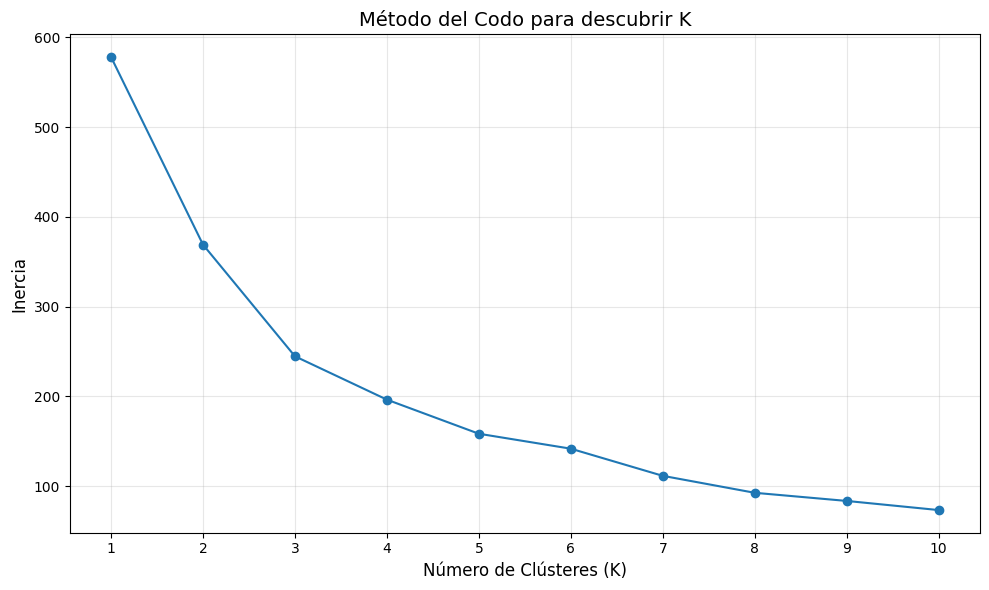

In [ ]:
inercia = []

K = range(1, 11)

for k in K:
    modelo_prueba = KMeans(n_clusters=k, random_state=67)
    modelo_prueba.fit(var_escalado)
    inercia.append(modelo_prueba.inertia_)

plt.figure(figsize=(10,6))


plt.plot(K, inercia, marker='o')


plt.title('Método del Codo para descubrir K', fontsize=14)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Inercia', fontsize=12)

plt.xticks(K)
plt.grid(alpha=0.3)


plt.tight_layout()
plt.show()


### Entrenamiento del modelo

In [ ]:
modelo_final = KMeans(n_clusters=4, random_state=67)

df_clientes_Unicos['Cluster_Asignado'] = modelo_final.fit_predict(var_escalado)
df_clientes_Unicos['Cluster_Asignado']

,Cluster_Asignado
0,3
1,0
2,3
3,1
4,1
...,...
284,3
285,2
286,1
287,0


### Resumen de Clusteres

Promedio de los valores observados en cada cluster

In [ ]:
resumen = df_clientes_Unicos.groupby('Cluster_Asignado')[['Margen_Rentabilidad_%','Puntaje_Fidelidad']].mean().round(2)

resumen

,Margen_Rentabilidad_%,Puntaje_Fidelidad
Cluster_Asignado,,
0,28.32,83.88
1,31.77,35.20
2,23.22,40.27
3,37.60,63.86


### Grafico de clusteres

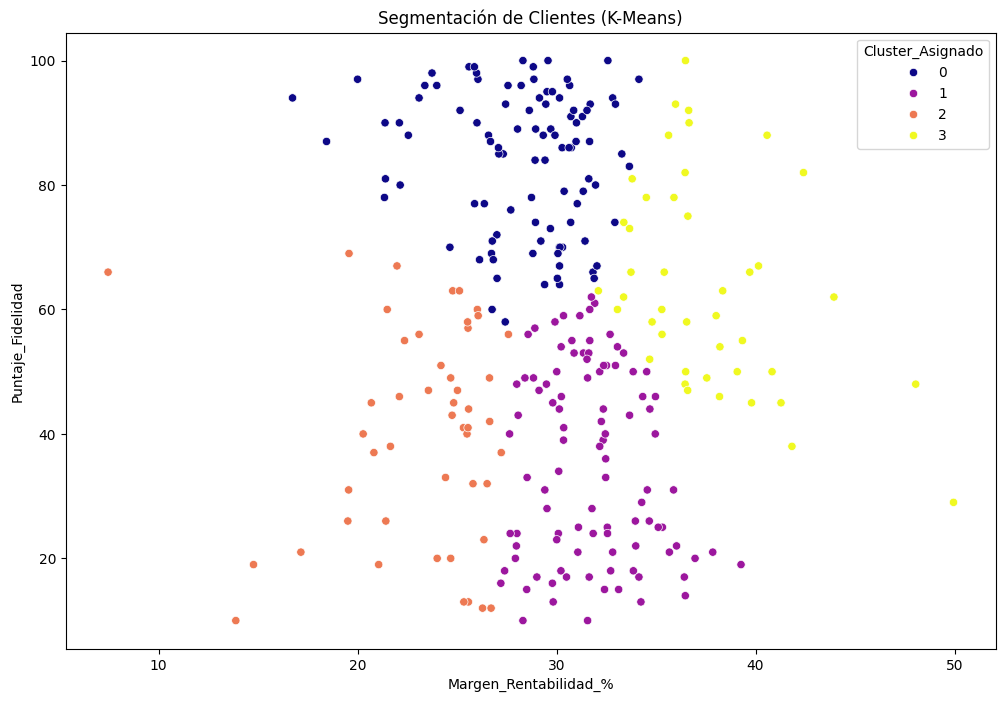

In [ ]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='Margen_Rentabilidad_%', y='Puntaje_Fidelidad', hue='Cluster_Asignado', data=df_clientes_Unicos, palette='plasma')
plt.title('Segmentación de Clientes (K-Means)')
plt.show()

In [ ]:
df_clientes_Unicos.head(10)

,ID_Cliente,Nombre_Cliente,Segmento,Puntaje_Fidelidad,Ventas,Ganancia,Margen_Rentabilidad_%,Cluster_Asignado
0,C0001,Fernanda Díaz,Consumidor,55,3908.37,1835.42,39.34,3
1,C0002,Valentina Muñoz,Home Office,58,20655.07,6567.03,27.42,0
2,C0003,Diego Castillo,Corporativo,100,7005.70,2551.35,36.48,3
3,C0004,Nicolás Silva,Corporativo,22,25636.41,8560.11,33.98,1
4,C0005,Daniela Rodríguez,Consumidor,36,27152.27,9017.95,32.47,1
5,C0006,Vicente Rojas,Home Office,78,30261.86,10139.25,28.74,0
6,C0007,Daniela López,Corporativo,97,22823.71,6717.39,28.86,0
7,C0008,Jorge Muñoz,Corporativo,18,36040.74,12705.12,27.39,1
8,C0009,Isidora Morales,Consumidor,60,16642.91,4098.42,21.49,2
9,C0010,Valentina Pérez,Consumidor,84,22068.18,6707.20,28.92,0


# **Seccion 2 - Analisis**

## Fase 2: Interpretacion de Segmentos

**Cluster 3: Clientes estrella (Alto margen y alta fidelidad)**

* **Comportamiento:** Son los clientes que presentan el mayor puntaje de fidelidad y, al mismo tiempo, el porcentaje de rentabilidad más elevado. Compran de manera frecuente y sus adquisiciones generan un excelente nivel de ganancia neta.
* **Por qué es relevante:** Son de vital importancia. Tienen el mayor peso en la salud financiera de SuperTienda, ya que constituyen el grupo ideal que sostiene a la empresa y asegura ingresos constantes mes a mes.
* **Relación con el negocio:** Tienen un excelente rendimiento operativo. Como ya confían en la marca, no requieren grandes inversiones en marketing para ser persuadidos. Generan compras orgánicas con buen margen, lo que permite que el costo logístico se compense sin mayor dificultad.
* **Comparación:** A diferencia del resto de los segmentos, este grupo es el único que presenta un desempeño positivo en ambas variables, sin mostrar puntos débiles.

**Cluster 1: Rentables ocasionales (Alto margen pero baja fidelidad)**

* **Comportamiento:** Estos clientes ofrecen un margen de rentabilidad alto, pero su puntaje de fidelidad es muy bajo. Son consumidores que realizan compras de gran valor, pero no vuelven a interactuar con la tienda a lo largo del tiempo.
* **Por qué es relevante:** Son un segmento clave porque representan un gran potencial de ingresos que actualmente se está perdiendo. Si se logra que estos usuarios realicen compras más recurrentes, las ganancias aumentarían considerablemente.
* **Relación con el negocio:** Aunque su nivel de ventas es excelente, evidencian un problema significativo en la retención de clientes. La empresa realiza todo el esfuerzo logístico y publicitario para atraerlos y enviarles el primer pedido, pero no logra fidelizarlos para el futuro.
* **Comparación:** Se asemejan al cluster 3 en la rentabilidad que generan, pero fallan de manera contundente en su nivel de lealtad.

**Cluster 0: Frecuentes poco lucrativos (Bajo margen pero alta fidelidad)**

* **Comportamiento:** Es un segmento que podría considerarse engañoso. Aparentan una fidelidad muy alta debido a su frecuencia, pero su margen de rentabilidad es bajo. Son usuarios que compran habitualmente en la tienda, pero aportan muy poca ganancia por transacción.
* **Por qué es relevante:** Tienen mucho peso en el volumen de operaciones y movimientos logísticos de la tienda, lo que puede dar una falsa sensación de éxito cuando, a nivel puramente financiero, su impacto es reducido.
* **Relación con el negocio:** A nivel operativo representan un desafío porque repetidamente podrían estar probablemente costando recursos como cajas, envíos y tiempo de los empleados para procesar sus pedidos a pesar de que dejan una ganancia neta mínima. Es probable que sean consumidores que compran frecuente o exclusivamente productos económicos o en promoción.
* **Comparación:** Son el opuesto directo del cluster 1. Interactúan constantemente, pero aportan escaso valor monetario en cada compra.

**Cluster 2: Segmento de baja prioridad (Bajo margen y baja fidelidad)**

* **Comportamiento:** Este segmento registra los valores más bajos en ambas variables. Tanto su margen de rentabilidad como su fidelidad son marcadamente deficientes.
* **Por qué es relevante:** Tienen muy poco peso en el crecimiento real del negocio. Son clientes que no aportan valor significativo a los objetivos comerciales de la empresa.
* **Relación con el negocio:** Con este grupo, la empresa apenas cubre costos o incluso directamente genera pérdidas. Cada pedido exige el mismo esfuerzo operativo y logístico que un cliente estrella, pero la ganancia es mínima y no parece existir proyección de fidelización a futuro.
* **Comparación:** Es el grupo menos atractivo en general. Carecen del buen margen que rescata al cluster 1 y de la lealtad constante que caracteriza al cluster 0.

## Fase 3: Narrativa Estrategica


### **Cluster 0:**

* **Contexto:**
Se analiza el segmento de clientes con alta fidelidad pero bajo margen de rentabilidad.

* **Hallazgo:**
El clustering mostró que estos clientes compran con frecuencia, pero generan una rentabilidad reducida por pedido. Su elevado nivel de actividad puede dar una percepción positiva del negocio, aunque su aporte económico es limitado.

* **Impacto:**
Este comportamiento incrementa la carga operativa y logística, ya que demanda procesamiento, envíos y recursos constantes con un retorno financiero bajo. La empresa debería buscar estrategias para aumentar el valor promedio de compra o mejorar el margen de los productos que consumen.


### **Clúster 1:**

* **Contexto:**
Se analiza el segmento de clientes con alto margen de rentabilidad pero baja fidelidad.

* **Hallazgo:**
El clustering reveló que estos clientes realizan compras de alto valor económico, pero no regresan a comprar con frecuencia. Existe una importante oportunidad de aumentar ingresos si se mejora su retención.

* **Impacto:**
La empresa obtiene buenas ganancias en la primera compra, pero pierde rentabilidad futura debido a la baja fidelización. Mejorar la retención de este segmento permitiría aprovechar mejor la inversión realizada en adquisición de clientes y aumentar los ingresos a largo plazo.

### **Cluster 2:**

* **Contexto:**
Se analiza el segmento de clientes con bajo margen de rentabilidad y baja fidelidad.

* **Hallazgo:**
El clustering identificó que este grupo presenta el menor aporte tanto en ganancias como en recurrencia de compra, siendo el segmento con menor valor para el negocio.
* **Impacto:**
Este comportamiento afecta negativamente la eficiencia financiera y logística, ya que cada pedido implica costos operativos similares a los de otros clientes, pero con escaso retorno económico y pocas probabilidades de generar ingresos futuros. Por ello, no representa una prioridad para las estrategias de crecimiento de la empresa.

### **Cluster 3:**

* **Contexto:**
Se analiza el segmento de clientes con alto margen de rentabilidad y alta fidelidad.

* **Hallazgo:**
El clustering permitió descubrir que este grupo combina simultáneamente los mayores niveles de rentabilidad y lealtad. No solo compra con frecuencia, sino que además cada compra genera un alto beneficio para la empresa.

* **Impacto:**
Este comportamiento fortalece la salud financiera de la empresa, ya que proporciona ingresos recurrentes con altos márgenes de ganancia. Además, al ser clientes fidelizados, requieren menores esfuerzos de captación, optimizando tanto los costos de marketing como los logísticos.


## Fase 4: Recomendaciones Accionables

 1. **Recomendación del Cluster 1:**
Como son clientes que generan una rentabilidad alta pero son poco frecuentes, les podemos ofrecer un descuento exclusivo con límite de tiempo (ej. válido por 30 días). Esto servirá para incentivar una segunda transacción rápida, antes de que el cliente se olvide de nuestra tienda.

2. **Recomendación del Cluster 0:**
Como son clientes de alta fidelidad pero con bajo margen de rentabilidad, podemos ofrecer la opción de un “día de entrega programado” (semanal o mensual) a cambio de envío gratuito. Con esto, reduciremos drásticamente el número de cajas y el costo logístico al empaquetar y transportar los productos todos juntos en un solo viaje.


## Fase 5: Limitaciones del Analisis

#### **1. Posibles limitaciones de tus datos:**
   * **Pérdida de Evolución Temporal por Agregación:** Para clasificar a los 289 clientes únicos, se agruparon todas sus compras históricas sumando ventas y promediando márgenes. Esto imposibilita analizar si un cliente del Cluster 1 (Rentables ocasionales) solía ser un cliente estrella en el pasado o si está reduciendo progresivamente su frecuencia de compra.

   * **Exclusión del Consumidor No Registrado:** La variable 'Puntaje_Fidelidad' solo aplica a usuarios registrados en la base de datos. Dado que el 58,5% de las compras totales del negocio se realizan sin registro, el modelo K-Means opera sobre una fracción de la masa de clientes, dejando fuera del clustering a casi el 60% de las ventas anónimas.

   * **Falta de Métricas de Costo Logístico y Satisfacción:** El indicador 'Margen_Rentabilidad_%' la rentabilidad teórica, pero omite variables como el costo de envío regional o el nivel de insatisfacción. Esto impide medir con precisión si el Cluster 0 (Frecuentes poco lucrativos) genera pérdidas operativas reales al procesar envíos de bajo margen, o cuánto dinero cuesta los 2.372 productos estancados en estado "Enviado".

#### **2. Supuestos realizados:**
   * **Efecto del Promedio (mean) en el Margen:** En lugar de la mediana, se utilizó el promedio simple para resumir el ‘Margen_Rentabilidad_%’ individual de cada cliente. Dado que la media es sensible a valores extremos, una sola compra atípica (muy alta o muy baja) puede inflar o distorsionar la rentabilidad general de un cliente y reubicarlo de clúster.

   * **Asignación Rígida de Clústeres** (Hard Clustering en K=4): A pesar de que el Método del Codo justificó la estructura de 4 grupos, K-Means impone fronteras estrictas. El modelo asume que no existen perfiles híbridos, forzando a clientes en los bordes (por ejemplo, con fidelidades cercanas a 60 puntos) a pertenecer de forma tajante al Cluster 0 o al Cluster 3.

   * **Homogeneización del Tipo de Cliente:** Al agrupar únicamente por margen y fidelidad, se asume implícitamente que un cliente Consumidor, Corporativo o Home Office actúa de la misma manera dentro del mismo clúster, ignorando sus distintas dinámicas de compra.


#### **3. Factores externos:**
   * **Contexto Económico e Inflación:** Los valores de los 4 clústeres se basan en datos históricos de precios. Cambios en la economía o inflación pueden reducir los márgenes de ganancia y hacer necesario recalibrar el modelo en el futuro.

   * **Distorsiones por Cadena de Suministro y Competencia:** La baja lealtad en el Cluster 2 (Baja prioridad) y en el Cluster 1 (con promedios de fidelidad de 40,27 y 35,20 puntos respectivamente) se interpreta como desinterés del cliente. Sin embargo, este comportamiento podría ser provocado por factores externos al dataset, como quiebres de stock en líneas clave (Muebles, Tecnología) o promociones agresivas de competidores directos.
